# Análise exploratória de dados
 - Conjunto de dados: Laptop Price
 - Cientistas de dados:
   - Ana Camila Conceição Rezende Silva
   - Everton Correia Silva
   - Lucas Pereira De Oliveira
   - Ítalo Lima Da Silva
---

## Preparação
 - Carregamento de bibliotecas
 - Configuração de estilo dos gráficos
 - Leitura do conjunto de dados

In [ ]:
import itertools
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import Markdown

sns.set_theme(style="whitegrid", palette="colorblind")

palette_dict = {
    'Company': 'tab20',
    'Product': 'Set3',
    'TypeName': 'Pastel1',
    'Ram': 'Dark2',
    'Memory': 'Set2',
    'OpSys': 'Accent'
}

In [ ]:
# @title Leitura do conjunto de dados
url = "https://raw.githubusercontent.com/omadson/datasets/main/datasets/laptop_price/laptop_price.csv"

df = pd.read_csv(url, encoding="latin1")
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
# @title Informações iniciais
display(Markdown("### Primeiras linhas"))
display(df.head())

display(Markdown("### Ultimas linhas"))
display(df.tail())

display(Markdown("### Informação das variáveis"))
df.info()

display(Markdown("### Quantidade de valores únicos"))
df.nunique()

### Primeiras linhas

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


### Ultimas linhas

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,1320,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


### Informação das variáveis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


### Quantidade de valores únicos

,0
laptop_ID,1303
Company,19
Product,618
TypeName,6
Inches,18
ScreenResolution,40
Cpu,118
Ram,9
Memory,39
Gpu,110


---
A partir das informações iniciais, podemos dizer que:
 - O conjunto de dados possui 1.303 registros e 13 variáveis.
 - Não foram identificados valores ausentes nas variáveis.
 - As variáveis `Inches`, `Price_euros` e `laptop_ID` foram inicialmente reconhecidas como numéricas.
 - As variáveis `Ram` e `Weight` foram reconhecidas como texto devido à presença das unidades de medida `GB` e `kg`. Por isso, precisaram ser convertidas para valores numéricos antes das análises estatísticas.
 - A variável `Product` possui 618 categorias diferentes, o que dificulta sua utilização direta em alguns gráficos e comparações.
 - A variável `laptop_ID` funciona apenas como identificador de cada registro e, por isso, não deve ser utilizada nos cálculos estatísticos, gráficos de distribuição ou análises de correlação.

---

## Descrição dos dados

In [ ]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "laptop_ID",
        "descricao": "Identificador único do notebook.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Company",
        "descricao": "Fabricante do notebook.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Product",
        "descricao": "Modelo do notebook.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "TypeName",
        "descricao": "Categoria do notebook (Ultrabook, Gaming, Notebook, etc.).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Inches",
        "descricao": "Tamanho da tela em polegadas.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "ScreenResolution",
        "descricao": "Resolução e tecnologia da tela.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Cpu",
        "descricao": "Modelo do processador.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Ram",
        "descricao": "Quantidade de memória RAM instalada.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Memory",
        "descricao": "Tipo e capacidade do armazenamento.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Gpu",
        "descricao": "Modelo da placa de vídeo.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "OpSys",
        "descricao": "Sistema operacional instalado.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Weight",
        "descricao": "Peso do notebook em quilogramas.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Price_euros",
        "descricao": "Preço do notebook em euros.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Touchscreen",
        "descricao": "Indica se a tela possui tecnologia touchscreen.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "IPS",
        "descricao": "Indica se a tela utiliza tecnologia IPS.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Resolution_X",
        "descricao": "Resolução horizontal da tela em pixels.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Resolution_Y",
        "descricao": "Resolução vertical da tela em pixels.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "PPI",
        "descricao": "Densidade de pixels por polegada da tela.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
])

df_dict

,variavel,descricao,tipo,subtipo
0,laptop_ID,Identificador único do notebook.,quantitativa,discreta
1,Company,Fabricante do notebook.,qualitativa,nominal
2,Product,Modelo do notebook.,qualitativa,nominal
3,TypeName,"Categoria do notebook (Ultrabook, Gaming, Note...",qualitativa,nominal
4,Inches,Tamanho da tela em polegadas.,quantitativa,contínua
5,ScreenResolution,Resolução e tecnologia da tela.,qualitativa,nominal
6,Cpu,Modelo do processador.,qualitativa,nominal
7,Ram,Quantidade de memória RAM instalada.,quantitativa,discreta
8,Memory,Tipo e capacidade do armazenamento.,qualitativa,nominal
9,Gpu,Modelo da placa de vídeo.,qualitativa,nominal


In [ ]:
# @title Pré-processamento

# ===========================
# RAM
# ===========================

df["Ram"] = (
    df["Ram"]
    .str.replace("GB", "", regex=False)
    .astype(int)
)

# ===========================
# Peso
# ===========================

df["Weight"] = (
    df["Weight"]
    .str.replace("kg", "", regex=False)
    .astype(float)
)

# ===========================
# Touchscreen
# ===========================

df["Touchscreen"] = (
    df["ScreenResolution"]
    .str.contains("Touchscreen", case=False)
    .astype(int)
)

# ===========================
# IPS
# ===========================

df["IPS"] = (
    df["ScreenResolution"]
    .str.contains("IPS", case=False)
    .astype(int)
)

# ===========================
# Resolução da tela
# ===========================

resolucao = df["ScreenResolution"].str.extract(r'(\d+)x(\d+)')

df["Resolution_X"] = resolucao[0].astype(int)
df["Resolution_Y"] = resolucao[1].astype(int)

# ===========================
# Pixels por polegada (PPI)
# ===========================

df["PPI"] = (
    np.sqrt(
        df["Resolution_X"]**2 +
        df["Resolution_Y"]**2
    )
) / df["Inches"]

df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   int64  
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   float64
 12  Price_euros       1303 non-null   float64
 13  Touchscreen       1303 non-null   int64  
 14  IPS               1303 non-null   int64  
 15  Resolution_X      1303 non-null   int64  
 16  Resolution_Y      1303 non-null   int64  


### Pré-processamento dos dados

As variáveis **Ram** e **Weight** estavam armazenadas como texto devido à presença das unidades de medida ("GB" e "kg"). Para possibilitar cálculos estatísticos e visualizações adequadas, essas colunas foram convertidas para valores numéricos.

## Análise univariada

In [ ]:
# @title Resumo estatístico

display(Markdown("### Variáveis qualitativas"))
print(df.describe(include='object'))

display(Markdown("### Variáveis quantitativas"))
print(df.describe())

### Variáveis qualitativas

       Company Product  TypeName   ScreenResolution  \
count     1303    1303      1303               1303   
unique      19     618         6                 40   
top       Dell  XPS 13  Notebook  Full HD 1920x1080   
freq       297      30       727                507   

                               Cpu     Memory                    Gpu  \
count                         1303       1303                   1303   
unique                         118         39                    110   
top     Intel Core i5 7200U 2.5GHz  256GB SSD  Intel HD Graphics 620   
freq                           190        412                    281   

             OpSys  
count         1303  
unique           9  
top     Windows 10  
freq          1072  


### Variáveis quantitativas

         laptop_ID       Inches          Ram       Weight  Price_euros  \
count  1303.000000  1303.000000  1303.000000  1303.000000  1303.000000   
mean    660.155794    15.017191     8.382195     2.038734  1123.686992   
std     381.172104     1.426304     5.084665     0.665475   699.009043   
min       1.000000    10.100000     2.000000     0.690000   174.000000   
25%     331.500000    14.000000     4.000000     1.500000   599.000000   
50%     659.000000    15.600000     8.000000     2.040000   977.000000   
75%     990.500000    15.600000     8.000000     2.300000  1487.880000   
max    1320.000000    18.400000    64.000000     4.700000  6099.000000   

       Touchscreen          IPS  Resolution_X  Resolution_Y          PPI  
count  1303.000000  1303.000000   1303.000000   1303.000000  1303.000000  
mean      0.147352     0.280123   1894.784344   1070.830391   146.635987  
std       0.354593     0.449231    494.641028    284.519410    43.121345  
min       0.000000     0.000000  

---
- A base de dados possui 1303 notebooks de 19 fabricantes diferentes, sendo a Dell a marca com maior número de registros.
- O tipo de notebook mais frequente é Notebook, enquanto o sistema operacional predominante é o Windows 10.
- A memória RAM mais comum é de 8 GB, e o armazenamento mais frequente é SSD de 256 GB.
- Os notebooks possuem, em média, 15 polegadas, peso médio de aproximadamente 2 kg e preço médio de 1123 euros.
- Após o pré-processamento, foi possível representar RAM e Weight como variáveis quantitativas e criar novos atributos derivados da tela, como Touchscreen, IPS e PPI, enriquecendo a análise exploratória.
---

### Distribuição de variáveis

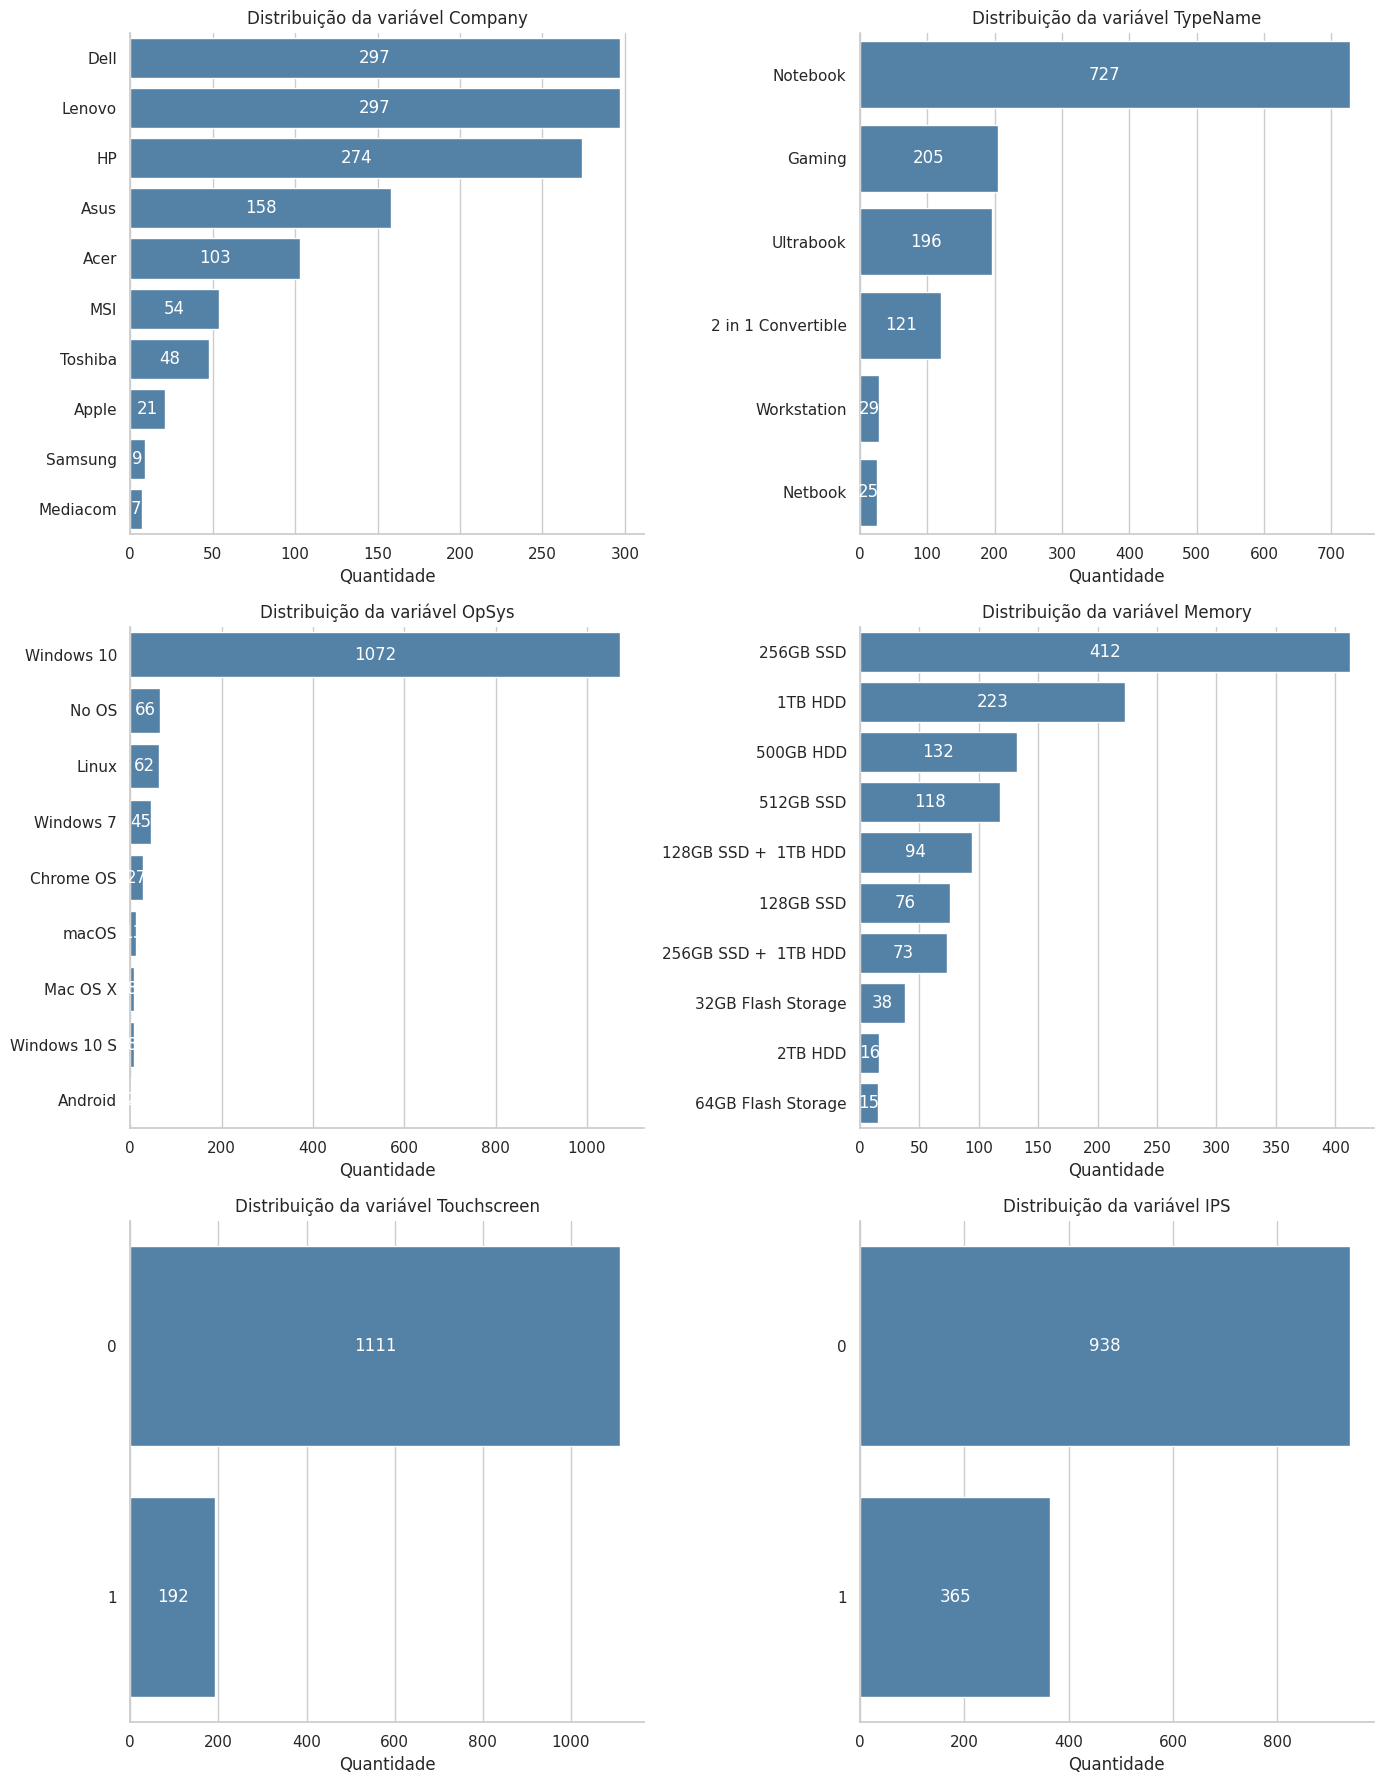

In [ ]:
# @title Variáveis qualitativas

variaveis_qualitativas = ["Company", "TypeName", "OpSys", "Memory", "Touchscreen", "IPS"]

fig, axes = plt.subplots(figsize=(14, 18), nrows=3, ncols=2)
axes = axes.flatten()

for i, variavel in enumerate(variaveis_qualitativas):

    order = df[variavel].value_counts().index[:10]   # mostra apenas os 10 mais frequentes

    ax = sns.countplot(
        data=df,
        y=variavel,
        order=order,
        ax=axes[i],
        color="steelblue"
    )

    ax.bar_label(
        ax.containers[0],
        fmt="%d",
        label_type="center",
        color="white"
    )

    ax.set(
        title=f"Distribuição da variável {variavel}",
        xlabel="Quantidade",
        ylabel=""
    )

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

---
 - A maioria dos notebooks pertence ao fabricante Dell, seguida por HP e Lenovo.
- O tipo de equipamento predominante é Notebook, enquanto Windows 10 é o sistema operacional mais utilizado.
- O armazenamento mais comum é SSD de 256 GB, refletindo a predominância de notebooks voltados ao uso cotidiano.
- A maior parte dos equipamentos não possui tela touchscreen, enquanto uma parcela considerável utiliza painéis IPS, indicando melhor qualidade de imagem em parte dos modelos analisados.
---

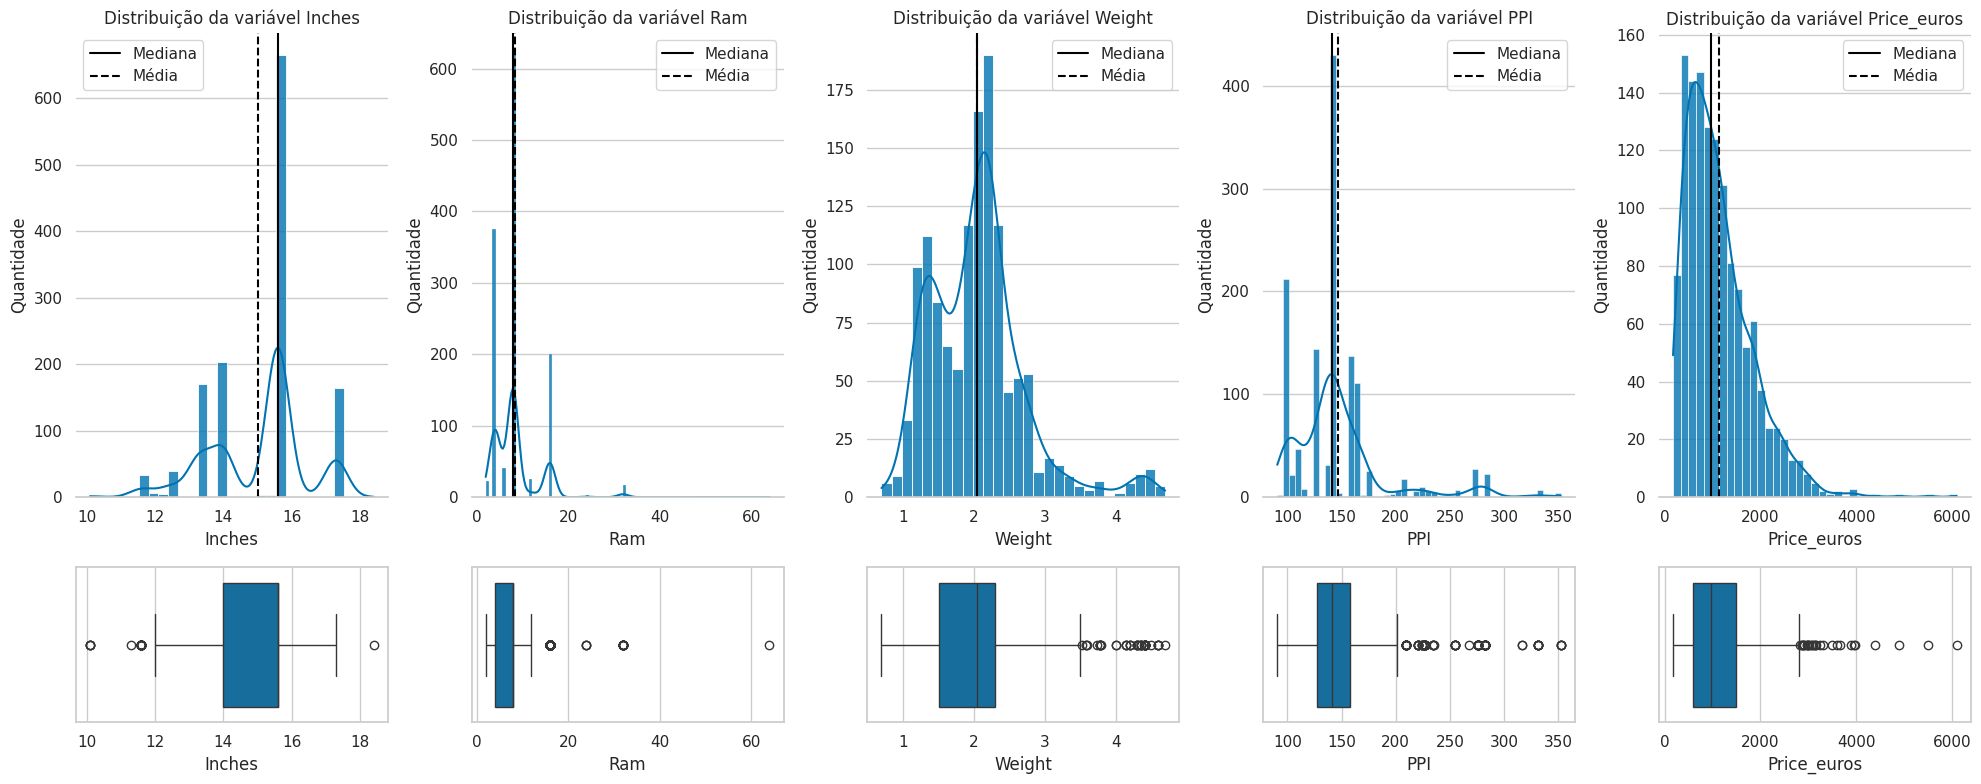

In [ ]:
# @title Variáveis quantitativas

variaveis_quantitativas = ["Inches", "Ram", "Weight", "PPI", "Price_euros"]

fig, axes = plt.subplots(
    figsize=(20,8),
    nrows=2,
    ncols=5,
    gridspec_kw={"height_ratios":[3,1]}
)

for i, variavel in enumerate(variaveis_quantitativas):

    # Histograma
    ax = sns.histplot(
        data=df,
        x=variavel,
        kde=True,
        ax=axes[0,i],
        alpha=.8
    )

    ax.axvline(df[variavel].median(),
               color="black",
               label="Mediana")

    ax.axvline(df[variavel].mean(),
               color="black",
               linestyle="--",
               label="Média")

    ax.set(
        title=f"Distribuição da variável {variavel}",
        ylabel="Quantidade"
    )

    ax.legend()

    ax.grid(False, axis="x")

    for side in ["left","top","right"]:
        ax.spines[side].set_visible(False)

    # Boxplot
    sns.boxplot(
        data=df,
        x=variavel,
        ax=axes[1,i]
    )

plt.tight_layout()
plt.show()

---
Distribuição da variável `Inches`
- A maior parte dos notebooks possui telas entre 14 e 16 polegadas.
- O tamanho mediano é de 15,6", muito próximo da média.
- Existem poucos modelos com telas muito pequenas (10") ou muito grandes (18"), caracterizando possíveis valores extremos.

Distribuição da variável `Ram`
 - A configuração de 8 GB é predominante no conjunto de dados.
- A média de memória RAM é próxima de 8 GB, embora existam notebooks com até 64 GB.
- Os modelos com 32 GB e 64 GB aparecem como valores pouco frequentes.

Distribuição da variável `Weight`
- A maior parte dos notebooks pesa entre 1,5 kg e 2,5 kg.
- A média e a mediana possuem valores muito próximos.

 Distribuição da variável `Price_euros`
- A maior parte dos notebooks possui preços entre aproximadamente €600 e €1.500.
- O preço médio é superior ao preço mediano, indicando uma distribuição assimétrica à direita.
- Existem notebooks com preços superiores a €4.000 (outliers).

Distribuição da variável `PPI`
- A densidade de pixels (PPI) apresenta concentração em uma faixa intermediária, indicando que a maior parte dos notebooks possui qualidade de tela semelhante.
- Alguns modelos apresentam PPI significativamente superior, normalmente associados a telas de alta resolução e equipamentos premium.
- A criação da variável PPI permitiu representar a qualidade da tela de forma mais adequada do que apenas utilizar sua resolução.
---

### Dados faltantes

In [ ]:
df.isnull().sum()

,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0


---

Não existem dados faltantes

---

## Análise bivariada

### Relação entre variáveis quantitativas

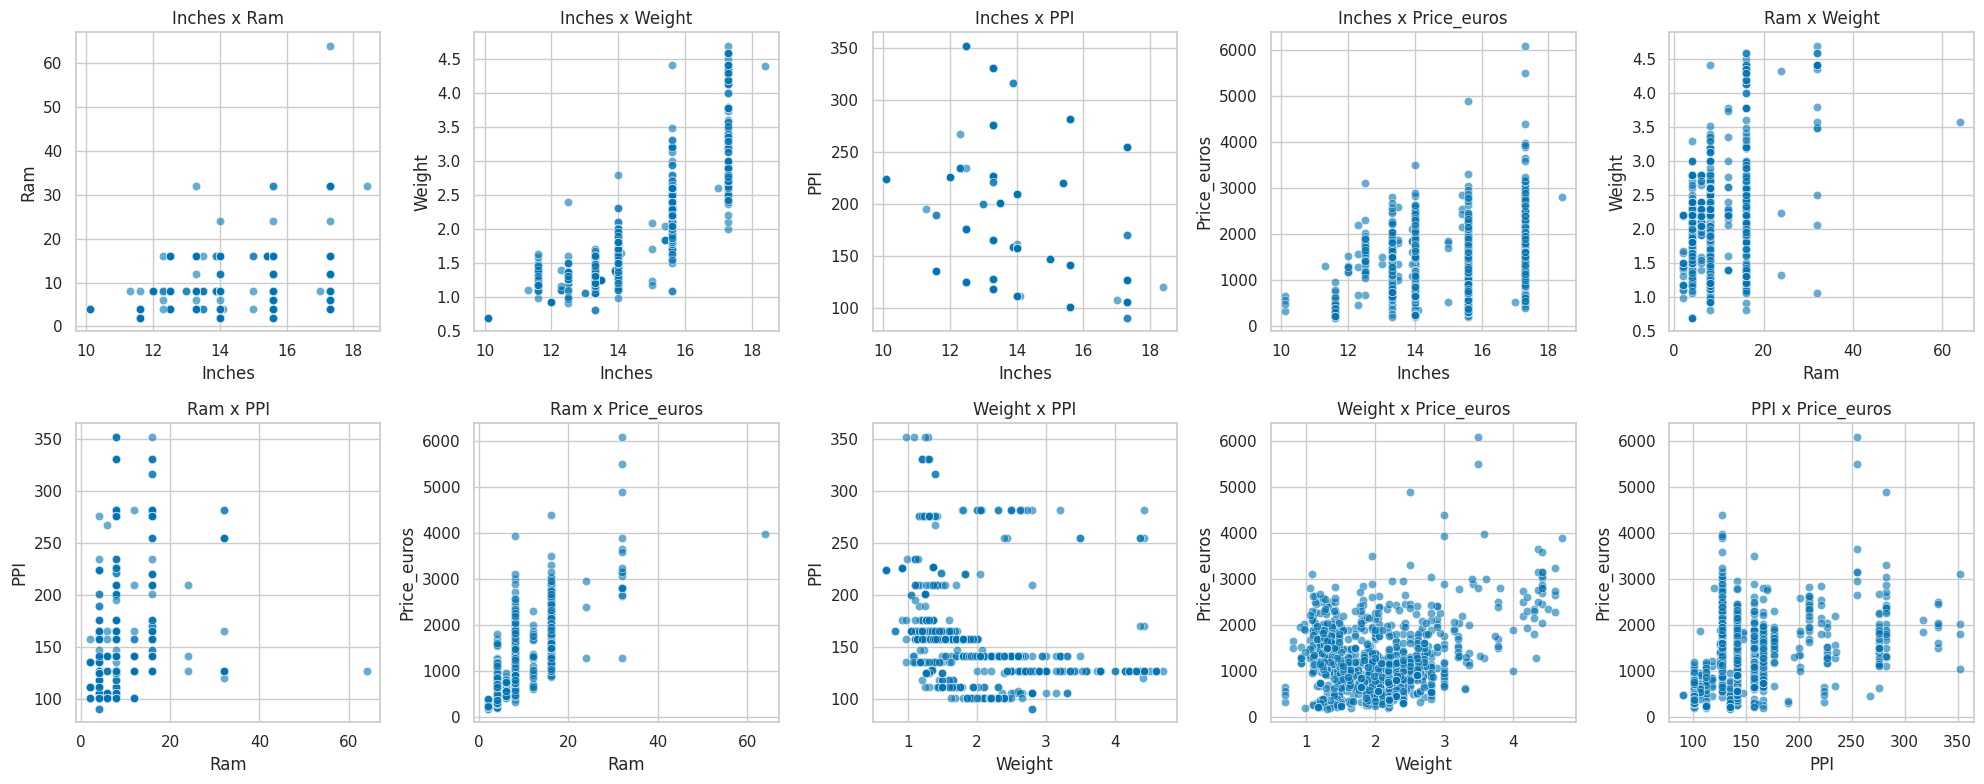

In [ ]:
# @title Relação entre pares de variáveis quantitativas

variaveis_quantitativas = [
    "Inches",
    "Ram",
    "Weight",
    "PPI",
    "Price_euros"
]

combinacoes = itertools.combinations(variaveis_quantitativas, 2)

fig, axes = plt.subplots(
    figsize=(20,8),
    ncols=5,
    nrows=2
)

axes = axes.flatten()

for i, (var1, var2) in enumerate(combinacoes):

    ax = sns.scatterplot(
        data=df,
        x=var1,
        y=var2,
        alpha=.6,
        ax=axes[i]
    )

    ax.set(
        title=f"{var1} x {var2}"
    )

plt.tight_layout()
plt.show()

---
- Existe uma tendência de notebooks com maior quantidade de memória RAM apresentarem preços mais elevados.
- Equipamentos com telas maiores tendem a possuir peso superior, embora essa relação não seja perfeitamente linear.
- O preço apresenta maior dispersão em relação às demais variáveis, indicando que fatores além do tamanho da tela e da memória RAM influenciam significativamente seu valor.
- Foram observados alguns pontos isolados (outliers), principalmente na relação entre RAM e preço, correspondendo a notebooks de alto desempenho.
- A variável PPI apresenta associação positiva com o preço dos notebooks, indicando que modelos com maior densidade de pixels tendem a possuir maior valor de mercado.
---

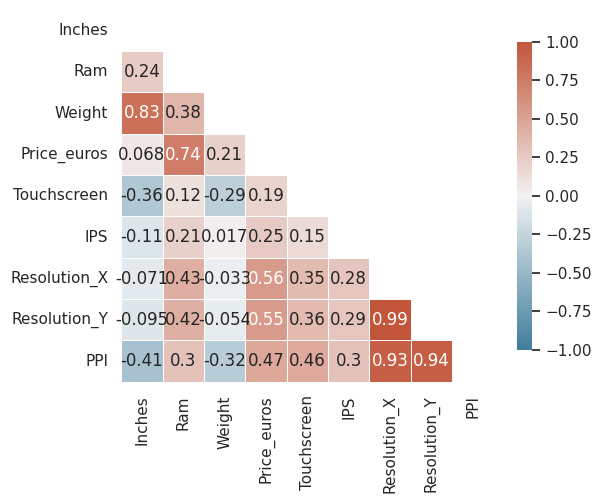

In [ ]:
# @title Correlação

corr = df.drop(columns=["laptop_ID"]).corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.set_style("white")

f, ax = plt.subplots(figsize=(6,5))

cmap = sns.diverging_palette(230,20,as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=.5,
    annot=True,
    cbar_kws={"shrink":.8},
    ax=ax
)

plt.show()

---
 - Uma das maiores correlações positivas foi observada entre Ram e Price_euros, indicando que notebooks com maior quantidade de memória RAM tendem a apresentar preços mais elevados.
---

### Relação entre variáveis qualitativas

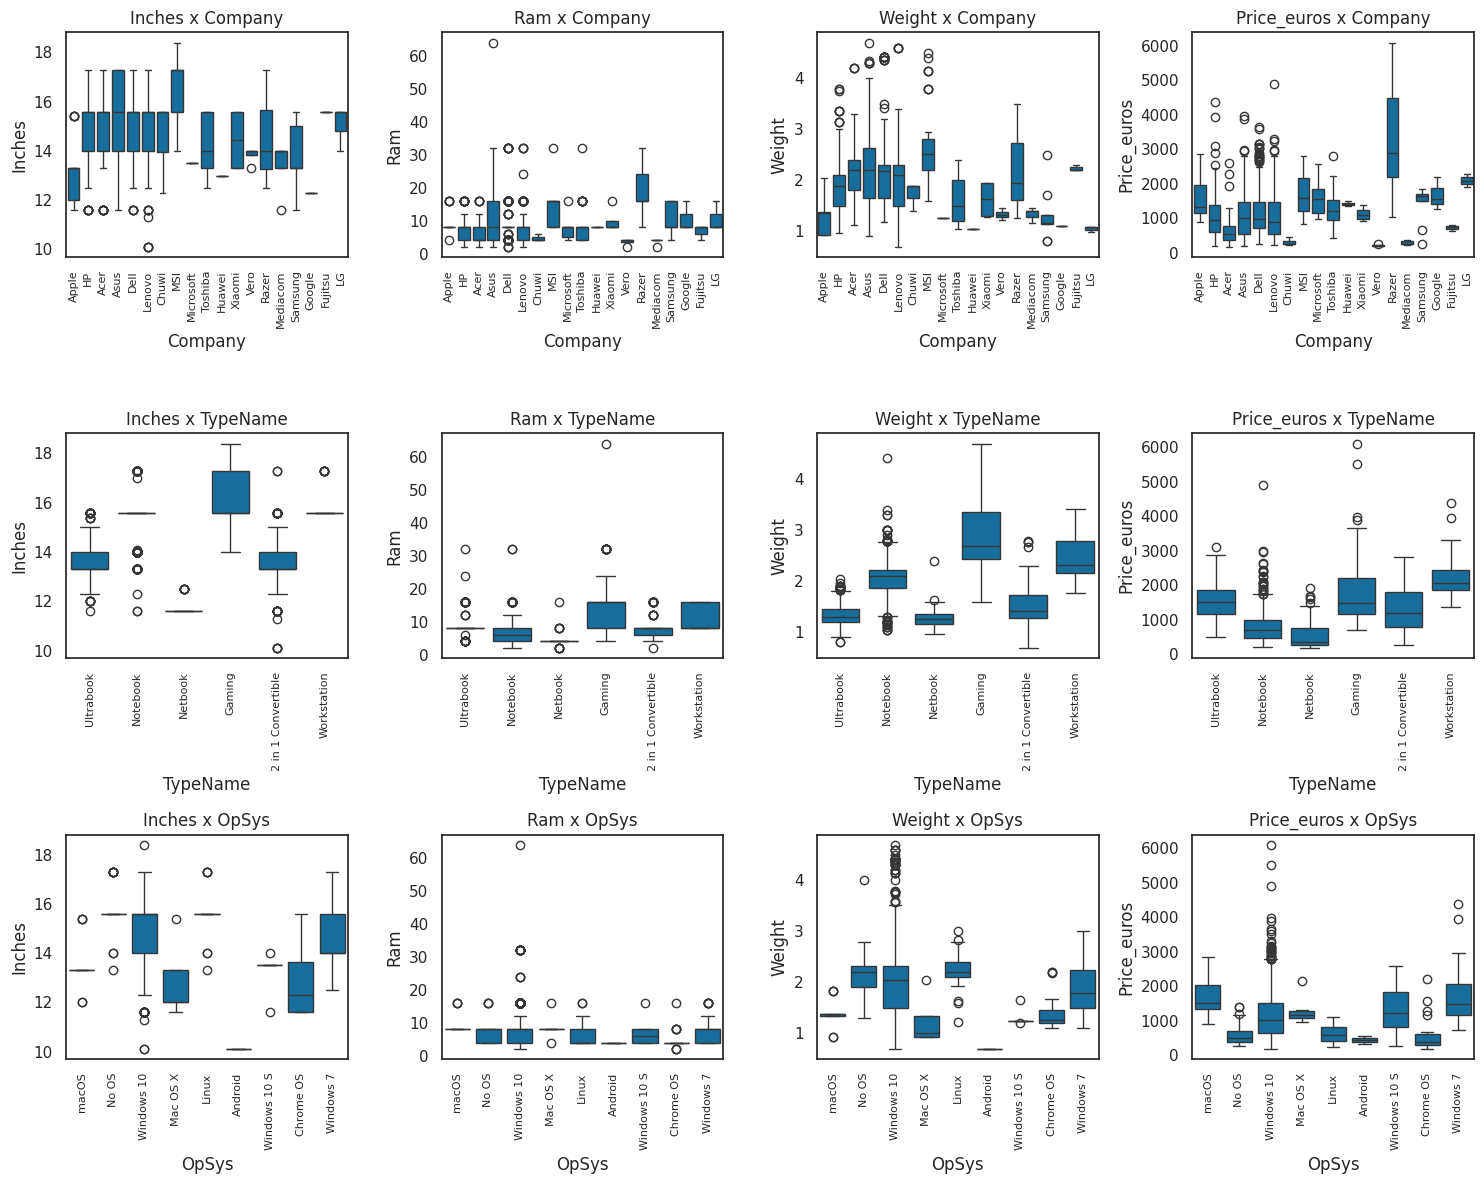

In [ ]:
# @title Distribuição relativa

variaveis_qualitativas = [
    "Company",
    "TypeName",
    "OpSys"
]

variaveis_quantitativas = [
    "Inches",
    "Ram",
    "Weight",
    "Price_euros"
]

combinacoes = list(
    itertools.product(
        variaveis_qualitativas,
        variaveis_quantitativas
    )
)

fig, axes = plt.subplots(
    figsize=(15,12),
    nrows=3,
    ncols=4
)

axes = axes.flatten()

for i, (qualitativa, quantitativa) in enumerate(combinacoes):

    sns.boxplot(
        data=df,
        x=qualitativa,
        y=quantitativa,
        ax=axes[i]
    )

    axes[i].set_title(f"{quantitativa} x {qualitativa}")
    axes[i].tick_params(axis="x", labelsize=8, rotation=90)

plt.tight_layout()
plt.show()

---
 - Os notebooks da categoria Gaming apresentam, em geral, maior peso e preços mais elevados quando comparados às demais categorias.
- Equipamentos com macOS tendem a possuir preços superiores à média da base, refletindo a predominância de modelos da Apple.
- Observa-se variação significativa dos preços entre os diferentes fabricantes, indicando que a marca influencia diretamente o posicionamento dos produtos no mercado.
- As distribuições também evidenciam a presença de valores extremos (outliers), principalmente na variável Price_euros, demonstrando a existência de notebooks premium com preços muito acima da média.
---

### Relação entre variáveis quantitativas e qualitativas

/tmp/ipykernel_1064/700380159.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_1064/700380159.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_1064/700380159.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_1064/700380159.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


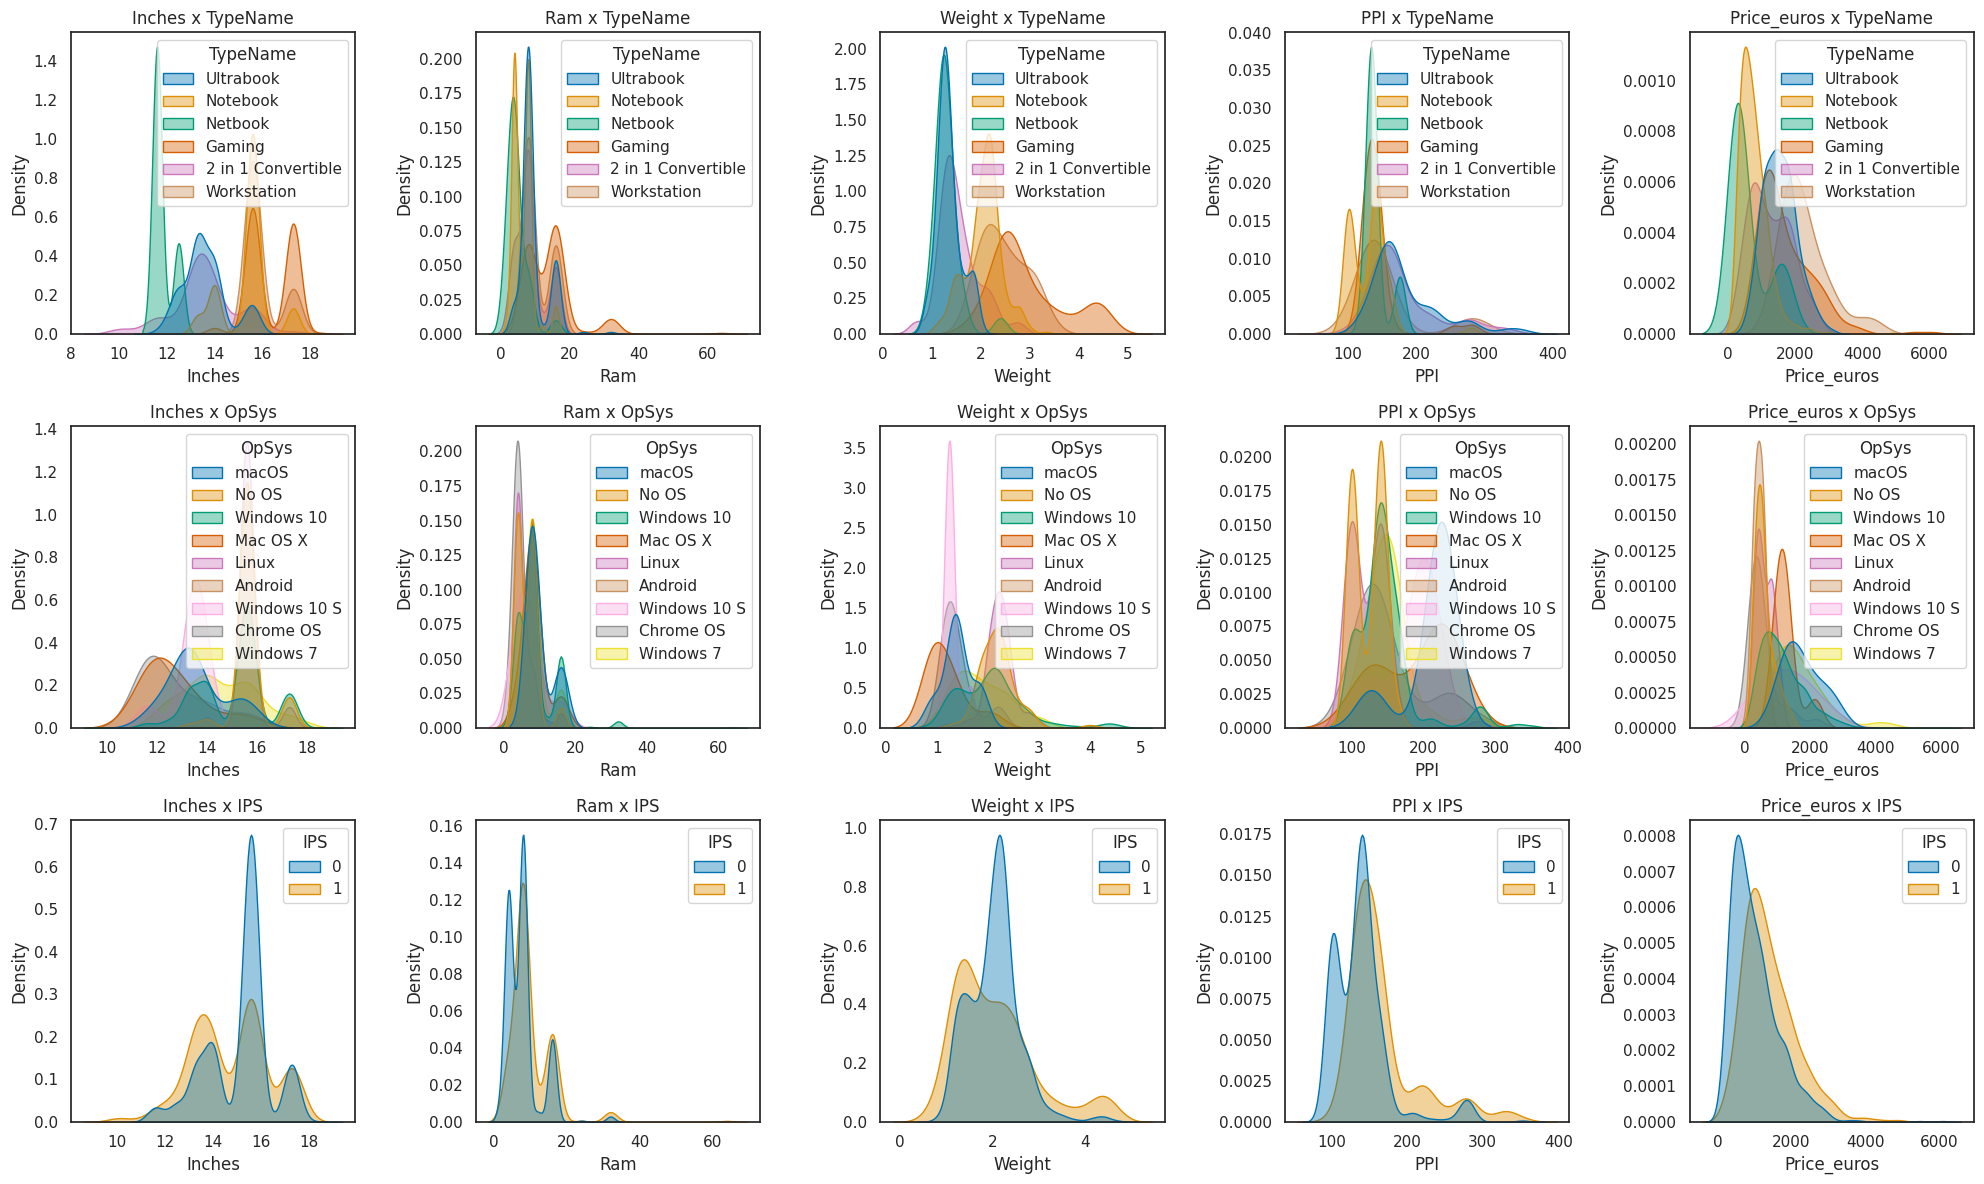

In [ ]:
# @title Distribuição relativa

variaveis_qualitativas = [
    "TypeName",
    "OpSys",
    "IPS"
]

variaveis_quantitativas = [
    "Inches",
    "Ram",
    "Weight",
    "PPI",
    "Price_euros"
]

fig, axes = plt.subplots(
    figsize=(20,12),
    nrows=3,
    ncols=5
)

axes = axes.flatten()

for i, (qualitativa, quantitativa) in enumerate(
        itertools.product(variaveis_qualitativas,
                          variaveis_quantitativas)):

    sns.kdeplot(
        data=df,
        x=quantitativa,
        hue=qualitativa,
        fill=True,
        common_norm=False,
        alpha=.4,
        ax=axes[i]
    )

    axes[i].set_title(f"{quantitativa} x {qualitativa}")

plt.tight_layout()
plt.show()

---

 - Os notebooks da categoria Gaming concentram os maiores valores de memória RAM, peso e preço, caracterizando equipamentos voltados para alto desempenho.
- Equipamentos classificados como Ultrabook apresentam, em geral, menor peso e preços intermediários, evidenciando o foco em portabilidade.
- Os notebooks com macOS apresentam distribuição de preços superior à dos demais sistemas operacionais, enquanto Windows 10 aparece distribuído em praticamente todas as faixas de preço.
- Observa-se que as distribuições das variáveis quantitativas variam de acordo com a categoria do notebook e o sistema operacional, indicando que esses atributos influenciam diretamente características como preço, memória e peso.
- Equipamentos com tela touchscreen apresentam, em média, preços superiores aos modelos convencionais.
- Modelos com tecnologia IPS também tendem a concentrar preços mais elevados, sugerindo que essa característica está associada a notebooks de maior desempenho ou categoria premium.

---

## Análise multivariada

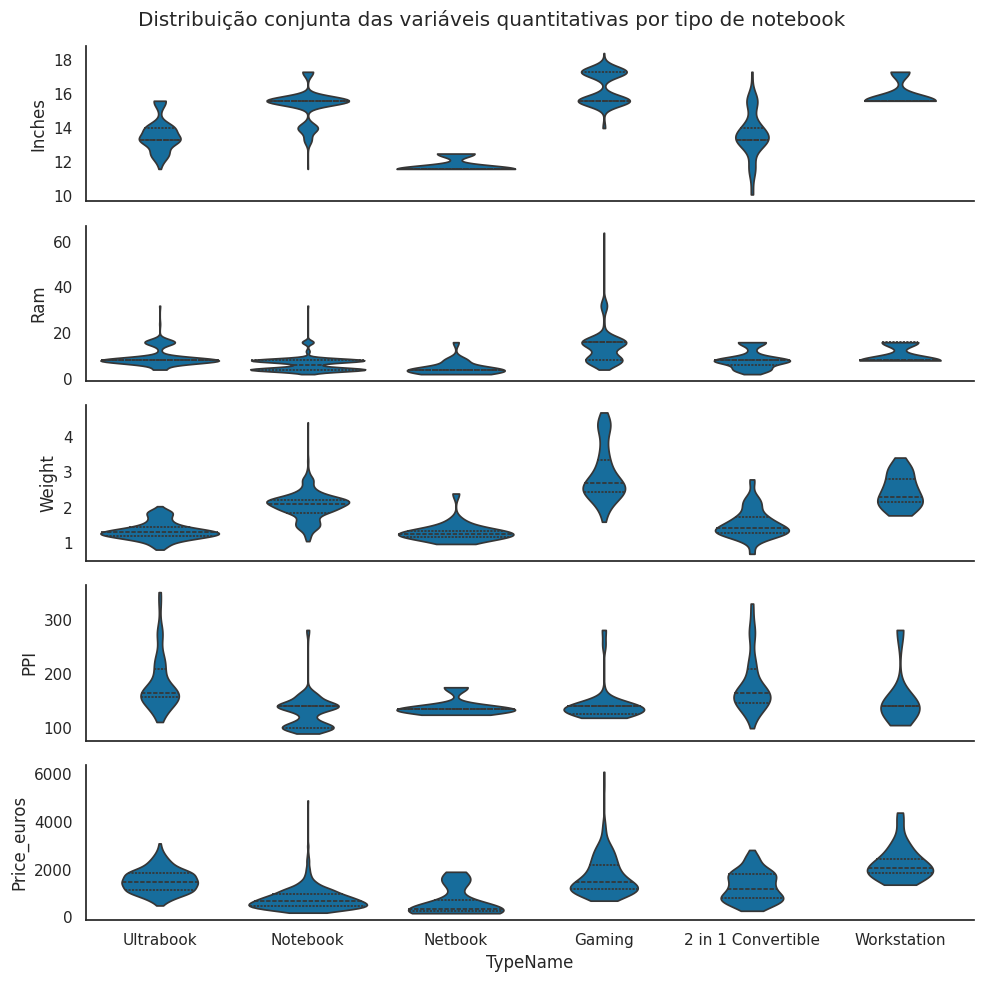

In [ ]:
# @title Distribuição conjunta

g = sns.PairGrid(
    df,
    y_vars=variaveis_quantitativas,
    x_vars=["TypeName"],
    height=3
)

g.fig.set_size_inches(10, 10)

g.map(
    sns.violinplot,
    inner="quart",
    cut=0
)

plt.suptitle(
    "Distribuição conjunta das variáveis quantitativas por tipo de notebook"
)

plt.tight_layout()

plt.show()

---
 - A categoria Gaming apresenta distribuições superiores de memória RAM, peso e preço, indicando notebooks voltados para maior desempenho.
- Os Ultrabooks concentram-se em menores valores de peso, reforçando sua característica de portabilidade.
- Os notebooks tradicionais apresentam maior concentração de modelos com 8 GB de RAM e preços intermediários.
- A análise conjunta evidencia que o tipo de notebook está associado simultaneamente a características físicas e econômicas, especialmente peso, memória e preço.
- Observou-se que notebooks com telas IPS, maior densidade de pixels (PPI) e maior quantidade de memória RAM concentram-se nas faixas de maior preço, indicando que essas características costumam aparecer simultaneamente em equipamentos de maior valor agregado.
 ---

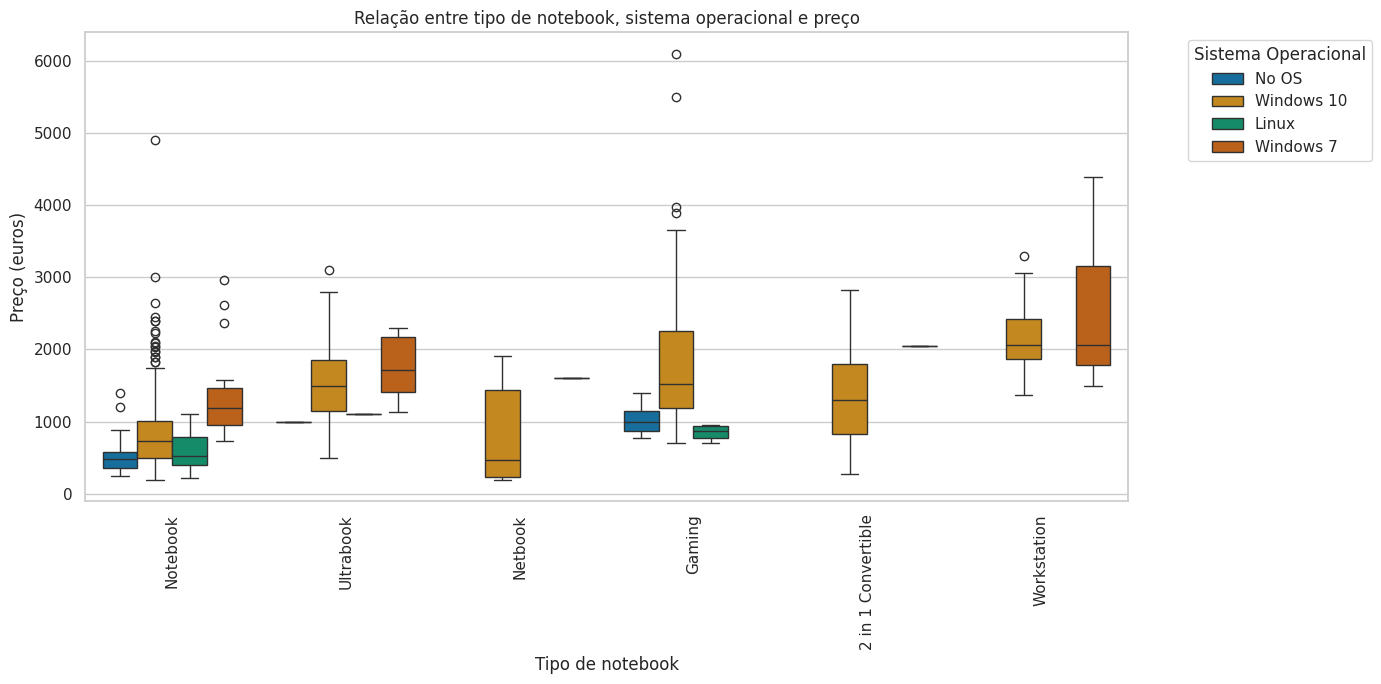

In [ ]:
# @title Contingência

sns.set_style("whitegrid")

top_opsys = df["OpSys"].value_counts().index[:4]

df_contingencia = df[
    df["OpSys"].isin(top_opsys)
]

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df_contingencia,
    x="TypeName",
    y="Price_euros",
    hue="OpSys"
)

ax.set_title(
    "Relação entre tipo de notebook, sistema operacional e preço"
)

ax.set_xlabel("Tipo de notebook")
ax.set_ylabel("Preço (euros)")

plt.xticks(rotation=90)

plt.legend(
    title="Sistema Operacional",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

---
 - A análise conjunta entre TypeName, OpSys e Price_euros evidencia diferenças no posicionamento dos notebooks de acordo com seu tipo e sistema operacional.
- Os notebooks da categoria Gaming apresentam, em geral, os maiores valores de preço e maior dispersão.
- Os equipamentos com macOS concentram-se em faixas de preço mais elevadas, enquanto os notebooks com Windows aparecem distribuídos em uma maior variedade de valores.
- A análise multivariada reforça que o preço dos notebooks está associado a diferentes características do produto, não sendo explicado por uma única variável isoladamente.

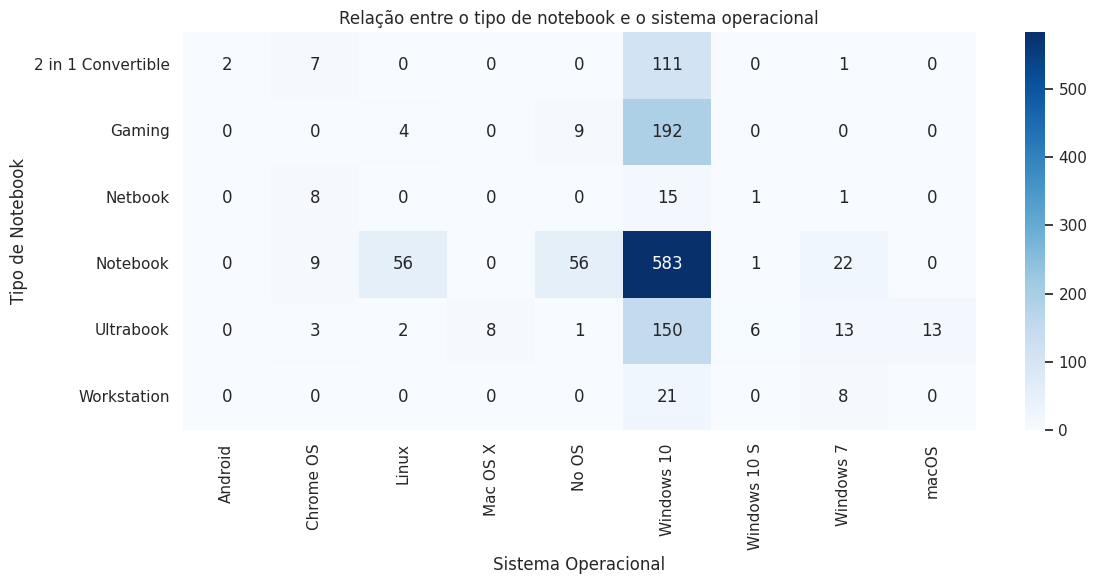

In [ ]:
# @title Contingência entre variáveis qualitativas

tabela_contingencia = pd.crosstab(
    df["TypeName"],
    df["OpSys"]
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    tabela_contingencia,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Relação entre o tipo de notebook e o sistema operacional"
)

plt.xlabel("Sistema Operacional")
plt.ylabel("Tipo de Notebook")

plt.tight_layout()
plt.show()

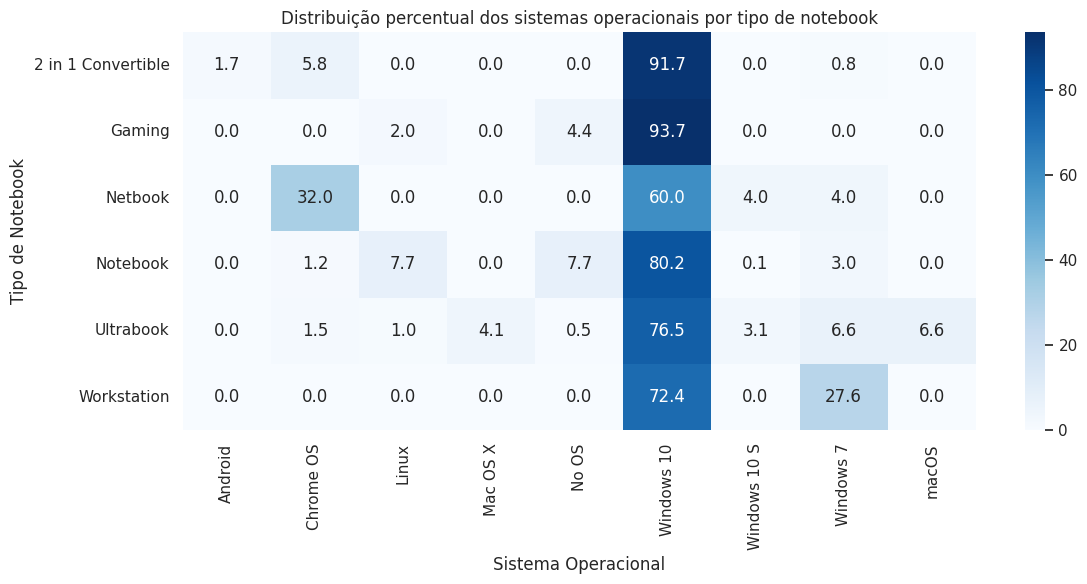

In [ ]:
# @title Distribuição relativa da contingência

tabela_percentual = pd.crosstab(
    df["TypeName"],
    df["OpSys"],
    normalize="index"
) * 100

plt.figure(figsize=(12, 6))

sns.heatmap(
    tabela_percentual,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title(
    "Distribuição percentual dos sistemas operacionais por tipo de notebook"
)

plt.xlabel("Sistema Operacional")
plt.ylabel("Tipo de Notebook")

plt.tight_layout()
plt.show()

---
 - A análise de contingência evidencia uma associação entre o tipo de notebook e o sistema operacional utilizado.
- O Windows 10 apresenta ampla distribuição entre diferentes categorias de notebooks, sendo predominante na base.
- Os notebooks associados ao macOS concentram-se principalmente em categorias relacionadas aos produtos da Apple, evidenciando uma forte associação entre o sistema operacional e o tipo de equipamento.
- As categorias de notebooks voltadas a maior desempenho, como Gaming e Workstation, apresentam predominância de sistemas Windows.
- A distribuição percentual permite observar que a relação entre as variáveis não é uniforme, indicando que o tipo de notebook está associado ao sistema operacional utilizado.

---

## Sumário de insights e hipóteses

- Foram criadas novas variáveis derivadas da resolução da tela, como Touchscreen, IPS e PPI, enriquecendo a base de dados e permitindo análises mais detalhadas sobre características dos notebooks.

- A base é composta principalmente por notebooks da categoria `Notebook`, com predominância da fabricante `Dell` e do sistema operacional `Windows 10`.

- A maior parte dos notebooks possui telas entre 14 e 15,6 polegadas e 8 GB de memória RAM. Existem, entretanto, equipamentos com configurações significativamente superiores, chegando a 64 GB de RAM.

- Os preços estão concentrados principalmente em faixas intermediárias, apresentando assimetria positiva e possíveis valores extremos acima de €4.000.

- Há uma relação positiva entre `Ram` e `Price_euros`, além de uma associação entre `Inches` e `Weight`. Notebooks `Gaming` e `Workstation` tendem a apresentar maiores valores de preço, peso e memória RAM.

- A análise de contingência indica uma associação entre `TypeName` e `OpSys`, com predominância do `Windows 10` na maior parte das categorias. Como hipótese para análises futuras, características de desempenho e configuração do equipamento podem exercer influência relevante sobre o preço dos notebooks.

fazer uma transformação para capturar a largura em pixel das telas, o pixel por polegadas da tela se é tpuck se é ips,